# Executed full workshop: CPU example

Executed on 8 October 2026 on an AMD Ryzen 7 3700X CPU (four torch threads),
CPython 3.11.17, using the compiled bytecode runtime 0.1.3.

**All 26 executable cells passed in 56.7 seconds**, with DaLiA and model weights
already downloaded. This is the full notebook with its default `quick` teaching
profile: six subjects, ten minutes each, three folds and up to twelve epochs.
It includes the model exercise, advanced API tour and Integrated Gradients.

This saved copy is for viewing outputs on GitHub. Open `../workshop.ipynb` from
the repository root to rerun it. Machine-specific output paths are replaced by
portable placeholders. Quick-profile metrics are illustrative, not benchmark results.


# PPG workshop: from wrist signals to held-out predictions

**Goal:** use an installed framework to build a reproducible heart-rate experiment on PPG-DaLiA, compare a small MLP with PaPaGei-S, and investigate where errors occur.

This notebook calls the framework for formatting, processing, HDF5 I/O, splits, normalization, model construction, training, metrics, downloads and plots. Configuration remains visible so you can explain and change each decision.

| Stage | What you learn | Output |
|---|---|---|
| Inspect and format | Signals, sampling rates, aligned labels | Shared dataset representation |
| Process and export | Resampling, windows, missing targets | Experiment-ready HDF5 |
| Split | Subject independence and training-only normalization | Saved split/transform JSON |
| Train | Specialized model and frozen foundation backbone | Predictions and run configs |
| Diagnose | Agreement, signed errors, violins, derivatives | Tables and PDF/PNG figures |
| Exercise | Change one decision under fixed splits | Comparable held-out results |

The quick mode uses six subjects and the first ten minutes per subject. It is a teaching subset, not a published benchmark reproduction. Full mode uses all subjects and complete recordings. Download DaLiA (~2.7 GB) **before** the live session; allow additional disk space for extraction. PaPaGei-S weights are ~23 MB.

The advanced tour (sections 16-21) adds streaming, custom transforms, filtering, fitted normalization, window sequences, persisted transformations, alternative splits, torch loaders and Integrated Gradients. Use the instructor agenda to choose the live-session pace.

## 1. Installation and workspace

Create the provided conda environment, activate it, install the public workshop package, and launch Jupyter from the workshop folder. The README contains exact commands. No checkout of the framework repository is required.

The cell below must run before importing processing/training modules. If you change the workspace after importing them, restart the kernel. The runtime ships as CPython 3.11 bytecode; it remains subject to reverse engineering.

In [1]:
from pathlib import Path
import os

WORKSPACE = Path(os.environ.get('PPG_WORKSPACE', Path.cwd())).expanduser().resolve()
os.environ['PPG_WORKSPACE'] = str(WORKSPACE)
from ppg_experiment_framework.workshop import create_workspace
create_workspace(WORKSPACE, task_names=('baseline', 'exercise'))
print('Workshop workspace:', WORKSPACE)

Workshop workspace: .


In [2]:
import json
from copy import deepcopy
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

from ppg_experiment_framework.workshop import pipeline, plots
from ppg_experiment_framework.workshop.downloads import download_file, extract_dalia
from ppg_experiment_framework.data_io.experiment_ready import load_experiment_ready_dataset

settings = pipeline.load_settings(WORKSPACE / 'configs/workshop.yaml')
MODE = os.environ.get('PPG_WORKSHOP_MODE', 'quick')  # 'quick' or 'full'
profile = settings[MODE]
SEED = settings['seed']
DEVICE = os.environ.get('PPG_WORKSHOP_DEVICE', 'cpu')
RUN_EXERCISE = True  # Set False for an instructor-only baseline walkthrough.
torch.set_num_threads(settings['torch_threads'])
plt.style.use('seaborn-v0_8-whitegrid')
FIGURES = WORKSPACE / 'figures'
DATA_ROOT = WORKSPACE / 'data/datasets/ppg+dalia'
ARTIFACT = f"dalia_{MODE}_{settings['sample_rate']:g}hz_{settings['window_seconds']:g}s"
FORMATTED = DATA_ROOT / 'formatted' / ARTIFACT
PROCESSED = DATA_ROOT / 'processed' / ARTIFACT
HDF5 = DATA_ROOT / 'experiment_ready' / f'{ARTIFACT}.h5'
display(pd.Series({'mode': MODE, 'subjects': profile['subjects'],
                   'seconds_per_subject': profile['max_duration_seconds'],
                   'device': DEVICE, 'seed': SEED, 'sample_rate_hz': settings['sample_rate']}))

<conda-environment>\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


mode                                      quick
subjects               [S1, S2, S3, S4, S5, S6]
seconds_per_subject                         600
device                                      cpu
seed                                        123
sample_rate_hz                            125.0
dtype: object

## 2. Download DaLiA and PaPaGei-S

DaLiA contains wrist BVP sampled at 64 Hz and ECG-derived heart-rate labels. Our formatter uses label centers starting at 4 seconds, spaced every 2 seconds, and the processing API constructs aligned 8-second windows.

Downloads are explicit, cached and atomic. PaPaGei weights are checked against the MD5 published by Zenodo (an integrity check). Only obtain these pickle-based data/model files from the documented trusted sources. To use an existing download, place it at the path below.

Sources: [DaLiA / UCI](https://doi.org/10.24432/C53890), [dataset readme](https://archive.ics.uci.edu/ml/machine-learning-databases/00495/readme.pdf), [PaPaGei weights](https://doi.org/10.5281/zenodo.13983110), [PaPaGei implementation](https://github.com/Nokia-Bell-Labs/papagei-foundation-model).

In [3]:
archive = download_file(settings['dalia']['url'], WORKSPACE / 'data/downloads/dalia_data.zip')
ORIGINAL = extract_dalia(archive, DATA_ROOT / 'original')
weight_settings = settings['papagei']
WEIGHTS = download_file(weight_settings['url'], WORKSPACE / 'weights/original/papagei-s/weights.pth',
                        checksum=weight_settings['checksum'], algorithm=weight_settings['algorithm'])
print('Raw subjects:', ORIGINAL)
print('Verified PaPaGei weights:', WEIGHTS)

Extracting DaLiA:   0%|          | 0/92 [00:00<?, ?file/s]

Extracting DaLiA: 100%|██████████| 92/92 [00:00<00:00, 7834.25file/s]

Raw subjects: .\data\datasets\ppg+dalia\original\PPG_FieldStudy
Verified PaPaGei weights: .\weights\original\papagei-s\weights.pth


## 3. Format and inspect the source representation

The formatter translates dataset-specific files to the common `attributes` + `value` representation. A record retains subject identity, BVP, heart-rate targets and their separate time axes. This is the same formatter used by the framework's DaLiA setup scripts.

**Discuss:** Why must the signal and target sampling rates be represented separately? What would go wrong if every BVP sample were treated as an independent labeled observation?

In [4]:
pipeline.format_dalia(ORIGINAL, FORMATTED, subject_ids=profile['subjects'],
                      max_duration_seconds=profile['max_duration_seconds'])
metadata = json.loads((FORMATTED / 'metadata.json').read_text())
records = np.load(FORMATTED / 'dataset.npy', allow_pickle=True)
display(pd.DataFrame([{'subject': r['attributes']['subject_id'],
                       'BVP_samples': len(r['value']['BVP']),
                       'HR_labels': len(r['value']['heart_rate'])} for r in records]))
display(pd.Series(metadata['frequency'], name='Sampling rate (Hz)'))

,subject,BVP_samples,HR_labels
0,S1,38400,298
1,S2,38400,298
2,S3,38400,298
3,S4,38400,298
4,S5,38400,298
5,S6,38400,298


BVP                64.0
heart_rate          0.5
time_BVP           64.0
time_heart_rate     0.5
Name: Sampling rate (Hz), dtype: float64

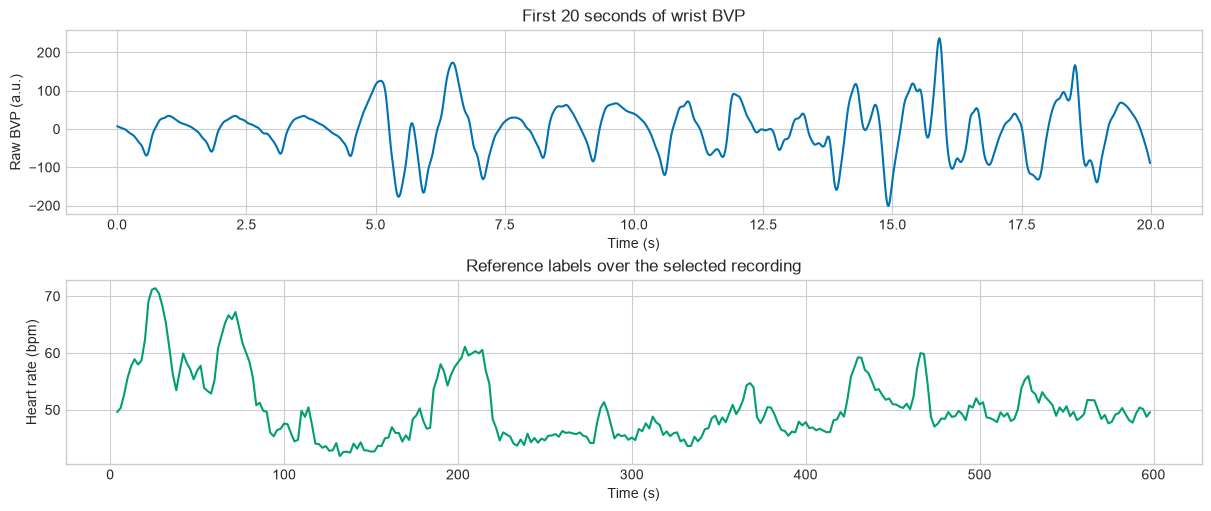

In [5]:
example = records[0]['value']
fig, axes = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)
visible = example['time_BVP'] < 20
axes[0].plot(example['time_BVP'][visible], example['BVP'][visible], color='#0072B2')
axes[0].set(xlabel='Time (s)', ylabel='Raw BVP (a.u.)', title='First 20 seconds of wrist BVP')
axes[1].plot(example['time_heart_rate'], example['heart_rate'], color='#009E73')
axes[1].set(xlabel='Time (s)', ylabel='Heart rate (bpm)', title='Reference labels over the selected recording')
plots.save_figure(fig, FIGURES, '01_raw_signal_and_labels')
plt.show()

## 4. Process with the framework

We resample to 125 Hz, use 8-second windows aligned to the heart-rate label centers, remove windows with missing targets, then export HDF5 grouped by subject. At 125 Hz the model sees 1,000 samples per window.

These steps are shown explicitly using `DataProcessor`. Normalization is deliberately deferred until the training subjects are known. Overlapping windows from one subject must stay in the same split role.

The example uses resampling and no additional band-pass filter. This is an explicit workshop preprocessing choice, not a claim to reproduce every setting of the PaPaGei paper.

In [6]:
HDF5.parent.mkdir(parents=True, exist_ok=True)
with pipeline.make_processor(FORMATTED, PROCESSED, artifact_name=ARTIFACT) as processor:
    processor.load(overwrite_h5=True)
    processor.resample(labels=['BVP'], target_fs=settings['sample_rate'],
                       method='interpolation', timestamps_mode='regenerate', processor_backend='sequential')
    processor.window(biosignal_labels=['BVP'], target_labels=['heart_rate'],
                     window_time_seconds=settings['window_seconds'], target_time_label='time_heart_rate',
                     signal_time_label='time_BVP', processor_backend='sequential')
    processor.impute(labels=['heart_rate'], method='complete_case', processor_backend='sequential')
    dataset = processor.make_experiment_ready(x_train_labels=['BVP'], y_train_labels=['heart_rate'],
                    hdf5_path=HDF5, group_by='subject_id', overwrite=True,
                    verify_integrity=True, export_batch_size=1024)
print(dataset)

2026-10-08 13:29:08,896 - DataProcessor - INFO - Auto-discovered and appended required time label: time_BVP


2026-10-08 13:29:08,898 - DataProcessor - INFO - Auto-discovered and appended required time label: time_heart_rate


2026-10-08 13:29:08,898 - DataProcessor - INFO - Converting .\data\datasets\ppg+dalia\formatted\dalia_quick_125hz_8s to HDF5.


2026-10-08 13:29:08,921 - DataProcessor - INFO - HDF5 conversion complete.


2026-10-08 13:29:08,932 - DataProcessor - INFO - Starting Resample (125.0Hz) with processor_backend=sequential.


...

Flushing in-memory dataset to disk: 100%|██████████| 6/6 [00:00<00:00, 344.24rec/s]

Export experiment-ready:   0%|          | 0/6 [00:00<?, ?it/s]

Flushing in-memory dataset to disk:   0%|          | 0/6 [00:00<?, ?rec/s]

Flushing in-memory dataset to disk: 100%|██████████| 6/6 [00:00<00:00, 666.71rec/s]

ExperimentReadyDataset(
  hdf5_path=.\data\datasets\ppg+dalia\experiment_ready\dalia_quick_125hz_8s.h5,
  n_samples=1782,
  group_by='group' (originally 'subject_id'),
  x_label_sets=['BVP'],
  y_label_sets=['heart_rate'],
  is_window_sequence=False
)


## 5. Inspect model-ready arrays and signal morphology

An experiment-ready HDF5 stores inputs, targets and a stable original sample index. The index links each prediction back to its waveform, even after folds reorder the samples. The framework can load slices without reading the whole dataset.

The derivative plots below use physical time spacing: the first derivative has units a.u./s and the second a.u./s². Differentiation amplifies noise; large derivatives can reflect motion artifacts as well as waveform morphology.

Example input shape: (4, 1000, 1)
Example target shape: (4, 1)


sample_index               0
entry_id                   0
group_key                 S1
group_id                  S1
source_recording_index     0
source_entry_index         0
dtype: object

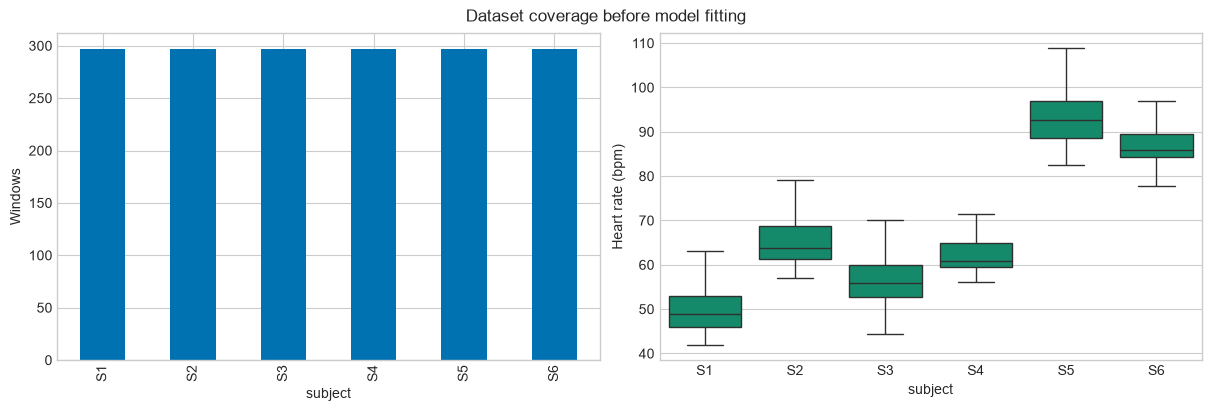

In [7]:
dataset = load_experiment_ready_dataset(HDF5)
print('Example input shape:', dataset.x_arrays[0][:4].shape)
print('Example target shape:', dataset.y_arrays[0][:4].shape)
display(pd.Series(dataset.sample_metadata(0)))
fig = plots.plot_target_distribution(dataset)
plots.save_figure(fig, FIGURES, '02_subject_coverage')
plt.show()

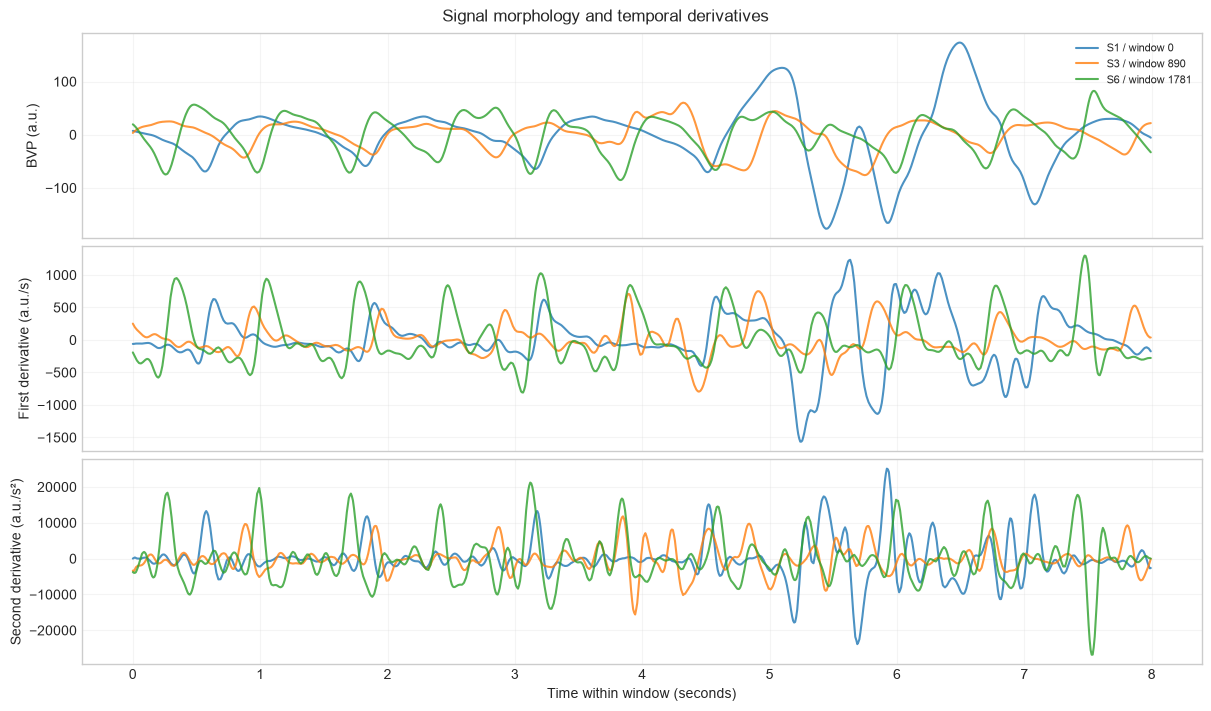

In [8]:
window_indices = np.linspace(0, dataset.n_samples - 1, 3, dtype=int).tolist()
fig = plots.plot_waveforms(dataset, indices=window_indices, sample_rate=settings['sample_rate'])
plots.save_figure(fig, FIGURES, '03_signals_and_derivatives')
plt.show()

## 6. Save subject-based splits and training-only normalization

Three outer folds hold out subjects for evaluation. Within each fold, a validation subject is separated for model selection. Training, validation and test subjects are disjoint. All models reuse the same split files.

The normalization artifact records the training subjects and fitted statistics. Validation/test inputs are transformed using those statistics; their values do not contribute to fitting them. The original HDF5 remains unnormalized for consistent signal diagnostics.

,fold,train,val,test
0,0,"S1, S2, S4",S5,"S3, S6"
1,1,"S1, S3, S4",S6,"S2, S5"
2,2,"S2, S3, S5",S6,"S1, S4"


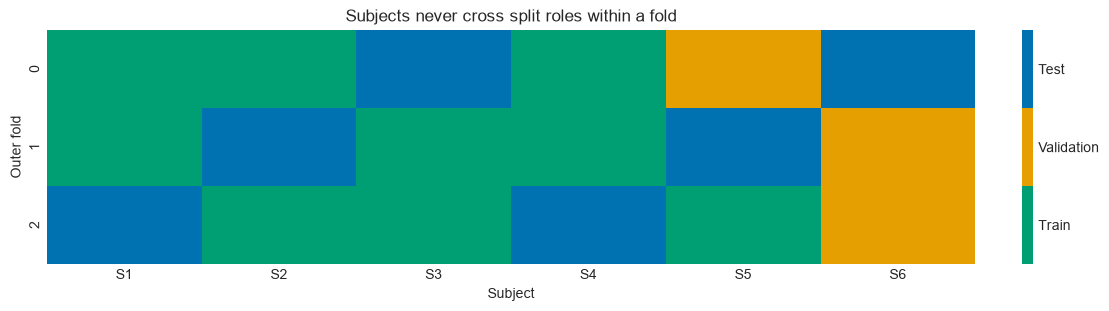

Normalization fit scope: train


In [9]:
split_path, transform_path = pipeline.save_training_splits(dataset, settings['split'],
        directory=HDF5.with_suffix('') / 'splits', val_fraction=settings['val_fraction'])
split_table = pipeline.split_summary(split_path)
display(split_table)
fig = plots.plot_splits(split_table)
plots.save_figure(fig, FIGURES, '04_subject_splits')
plt.show()
normalization = json.loads(transform_path.read_text())
print('Normalization fit scope:', normalization['transforms'][0]['fit_scope'])

## 7. Worked example: a specialized MLP

A base-model config specifies the torch network; an experiment config specifies training, testing and saving. The framework constructs and trains the model through its existing static orchestrator and `TorchTrainingBackend`.

First inspect a dry run, then perform the actual run. A dry run checks path/config resolution; only the following training cell validates the complete workflow. Training is deliberately small in quick mode. Metrics from this subset are exploratory.

In [10]:
mlp_config = pipeline.load_settings(WORKSPACE / 'configs/mlp.yaml')
mlp_config['backbone']['params']['signal_length'] = int(settings['sample_rate'] * settings['window_seconds'])
experiment_config = pipeline.load_settings(WORKSPACE / 'configs/experiment.yaml')
experiment_config['training']['n_epochs'] = profile['epochs']
experiment_config['training']['device'] = DEVICE
experiment_config['testing']['device'] = DEVICE
experiment_config['split_configs'] = [settings['split']]
display(pd.Series(mlp_config['backbone']['params']))
display(pipeline.describe_model(mlp_config))
display(pd.Series(experiment_config['training']))
pipeline.run_task(dataset=dataset, base_config=mlp_config, experiment_config=experiment_config,
                  split_path=split_path, transform_path=transform_path,
                  output_dir='results/baseline_mlp', seed=SEED, dry_run=True)

in_channels          1
signal_length     1000
hidden_size        128
output_size          1
dropout_prob       0.2
unfreeze_from        0
verbose          False
dtype: object

,component,type,parameters,trainable
0,fc1,Linear,128128,128128
1,fc2,Linear,129,129
2,relu,ReLU,0,0
3,dropout,Dropout,0,0


backend                                                                 torch
n_epochs                                                                   12
batch_size                                                                 64
learning_rate                                                           0.003
dataloader_seed                                                           123
device                                                                    cpu
loading_mode                                                     ram_prefetch
cache_in_memory                                                          True
num_workers                                                                 0
pin_memory                                                              False
drop_last                                                               False
shuffle                                                                  True
persistent_workers                                              

[DRY-RUN] Static orchestrator configuration parsed.
[DRY-RUN] base_model_config: in_memory_base_model_config
[DRY-RUN] head_model_config: None
[DRY-RUN] experiment_config: in_memory_experiment_config
[DRY-RUN] dataset_path: .\data\datasets\ppg+dalia\experiment_ready\dalia_quick_125hz_8s.h5
[DRY-RUN] dataset_exists: True
[DRY-RUN] dataset_mode: classic
[DRY-RUN] test_dataset_path: .\data\datasets\ppg+dalia\experiment_ready\dalia_quick_125hz_8s.h5
[DRY-RUN] test_dataset_exists: True
[DRY-RUN] loading_mode: ram_prefetch
[DRY-RUN] in_memory: True
[DRY-RUN] eval_loading_mode: ram_prefetch
[DRY-RUN] eval_in_memory: True
[DRY-RUN] split_configs: 1
[DRY-RUN] split_artifact_path: .\data\datasets\ppg+dalia\experiment_ready\dalia_quick_125hz_8s\splits\group_splits.json
[DRY-RUN] split_artifact_exists: True
[DRY-RUN] split_transform_artifact_path: .\data\datasets\ppg+dalia\experiment_ready\dalia_quick_125hz_8s\splits\normalization.json
[DRY-RUN] split_transform_artifact_exists: True


{'base_model_config': WindowsPath('in_memory_base_model_config'),
 'head_model_config': None,
 'experiment_config': WindowsPath('in_memory_experiment_config'),
 'dataset_path': WindowsPath('./data/datasets/ppg+dalia/experiment_ready/dalia_quick_125hz_8s.h5'),
 'dataset_exists': True,
 'dataset_mode': 'classic',
 'test_dataset_path': WindowsPath('./data/datasets/ppg+dalia/experiment_ready/dalia_quick_125hz_8s.h5'),
 'test_dataset_exists': True,
 'loading_mode': 'ram_prefetch',
 'in_memory': True,
 'eval_loading_mode': 'ram_prefetch',
 'eval_in_memory': True,
 'split_configs': 1,
 'split_artifact_path': WindowsPath('./data/datasets/ppg+dalia/experiment_ready/dalia_quick_125hz_8s/splits/group_splits.json'),
 'split_artifact_exists': True,
 'split_transform_artifact_path': WindowsPath('./data/datasets/ppg+dalia/experiment_ready/dalia_quick_125hz_8s/splits/normalization.json'),
 'split_transform_artifact_exists': True}

In [11]:
mlp_run = pipeline.run_task(dataset=dataset, base_config=mlp_config, experiment_config=experiment_config,
                  split_path=split_path, transform_path=transform_path,
                  output_dir='results/baseline_mlp', seed=SEED)
mlp_predictions = pipeline.prediction_table(mlp_run, model_name='MLP')
display(pipeline.regression_metrics(mlp_predictions))

2026-10-08 13:29:11,677 - StaticExperimentOrchestrator - INFO - Pre-embedding disabled (backend=torch, frozen=False).


2026-10-08 13:29:11,677 - TorchTrainingBackend - INFO - Resolved training device=cpu, cuda_available=False.


2026-10-08 13:29:11,678 - StaticExperimentOrchestrator - INFO - Reloading original experiment-ready arrays for split 0.


2026-10-08 13:29:11,686 - StaticExperimentOrchestrator - INFO - Applying split-specific transforms for split 0 in RAM (batch_size=64).


Split 0 transform x_0:   0%|          | 0/28 [00:00<?, ?it/s]

...

2026-10-08 13:29:14,503 - TorchTrainingBackend - INFO - Config 1/1 done: best_val_loss=1265.265515


2026-10-08 13:29:14,669 - StaticExperimentOrchestrator - INFO - Moved fitted split model to CPU after prediction.


Completed static PulsePPG orchestrator run with 3 split payload entries.

Run directory: .\results\baseline_mlp\run_3
Final results CSV: .\results\baseline_mlp\run_3\final_results_baseline_mlp.csv


,model,n,MAE,RMSE,R2,Pearson_r,bias
0,MLP,1782,34.553158,40.42593,-4.146001,0.187606,-26.725357


## 8. Foundation-model example: frozen PaPaGei-S + MLP head

The backbone supplies 512-dimensional embeddings. Its pretrained parameters are frozen; the framework trains a task-specific head. Frozen embeddings are computed by the existing runner, after applying the normalization belonging to each split.

**Discuss:** Which parameters are learned from DaLiA here? How would a frozen-backbone experiment differ from fine-tuning? We retain the same subject splits and input windows so the comparison is interpretable.

In [12]:
papagei_config = pipeline.load_settings(WORKSPACE / 'configs/papagei_s.yaml')
head_config = pipeline.load_settings(WORKSPACE / 'configs/head.yaml')
print('Backbone mode:', papagei_config['foundation_train_mode'])
display(pd.Series(head_config['head']['params']))
display(pipeline.describe_model(papagei_config, head_config=head_config))
papagei_run = pipeline.run_task(dataset=dataset, base_config=papagei_config, head_config=head_config,
                  experiment_config=experiment_config, split_path=split_path, transform_path=transform_path,
                  output_dir='results/baseline_papagei', seed=SEED)
papagei_predictions = pipeline.prediction_table(papagei_run, model_name='PaPaGei-S')
predictions = pd.concat([mlp_predictions, papagei_predictions], ignore_index=True)
assert set(mlp_predictions.sample_index) == set(papagei_predictions.sample_index)
display(pipeline.regression_metrics(predictions))

Backbone mode: frozen


d_model                                                      512
out_classes                                                    1
mlp_config     {'hidden_dims': [512, 256], 'dropout': 0.1, 'a...
dtype: object

❄️ Freezing block 0 of ResNET backbone
❄️ Freezing block 1 of ResNET backbone
❄️ Freezing block 2 of ResNET backbone
❄️ Freezing block 3 of ResNET backbone
❄️ Freezing block 4 of ResNET backbone
❄️ Freezing block 5 of ResNET backbone
❄️ Freezing block 6 of ResNET backbone
❄️ Freezing block 7 of ResNET backbone
❄️ Freezing block 8 of ResNET backbone
❄️ Freezing block 9 of ResNET backbone
❄️ Freezing block 10 of ResNET backbone
❄️ Freezing block 11 of ResNET backbone
❄️ Freezing block 12 of ResNET backbone
❄️ Freezing block 13 of ResNET backbone
❄️ Freezing block 14 of ResNET backbone
❄️ Freezing block 15 of ResNET backbone
❄️ Freezing block 16 of ResNET backbone
❄️ Freezing block 17 of ResNET backbone
❄️ Freezing block 18 of ResNET backbone
❄️ Freezing last block block 18 of ResNET backbone


,component,type,parameters,trainable
0,backbone,Net,5785612,0
1,head,Net,395777,395777


❄️ Freezing block 0 of ResNET backbone
❄️ Freezing block 1 of ResNET backbone
❄️ Freezing block 2 of ResNET backbone
❄️ Freezing block 3 of ResNET backbone
❄️ Freezing block 4 of ResNET backbone
❄️ Freezing block 5 of ResNET backbone
❄️ Freezing block 6 of ResNET backbone
❄️ Freezing block 7 of ResNET backbone
❄️ Freezing block 8 of ResNET backbone
❄️ Freezing block 9 of ResNET backbone
❄️ Freezing block 10 of ResNET backbone
❄️ Freezing block 11 of ResNET backbone
❄️ Freezing block 12 of ResNET backbone
❄️ Freezing block 13 of ResNET backbone
❄️ Freezing block 14 of ResNET backbone
❄️ Freezing block 15 of ResNET backbone
❄️ Freezing block 16 of ResNET backbone


...

2026-10-08 13:29:24,227 - TorchTrainingBackend - INFO - Epoch 12/12: train=237.064222 val=773.658606


2026-10-08 13:29:24,229 - TorchTrainingBackend - INFO - Config 1/1 done: best_val_loss=328.849358


2026-10-08 13:29:24,393 - StaticExperimentOrchestrator - INFO - Moved fitted split model to CPU after prediction.


Completed static PulsePPG orchestrator run with 3 split payload entries.
Run directory: .\results\baseline_papagei\run_3
Final results CSV: .\results\baseline_papagei\run_3\final_results_baseline_papagei.csv


,model,n,MAE,RMSE,R2,Pearson_r,bias
0,MLP,1782,34.553158,40.425930,-4.146001,0.187606,-26.725357
1,PaPaGei-S,1782,18.978268,23.730955,-0.773292,-0.422765,-8.782920


## 9. Agreement and error against prediction

We define signed error as **prediction − reference**: positive means overestimation. MAE/RMSE retain bpm units; R² may be negative; Pearson r measures association and does not establish agreement.

Each point below is a held-out window. Error against prediction and error against reference answer different questions and have mathematical coupling, so interpret them descriptively. These plots are not evidence that one input feature causes an error.

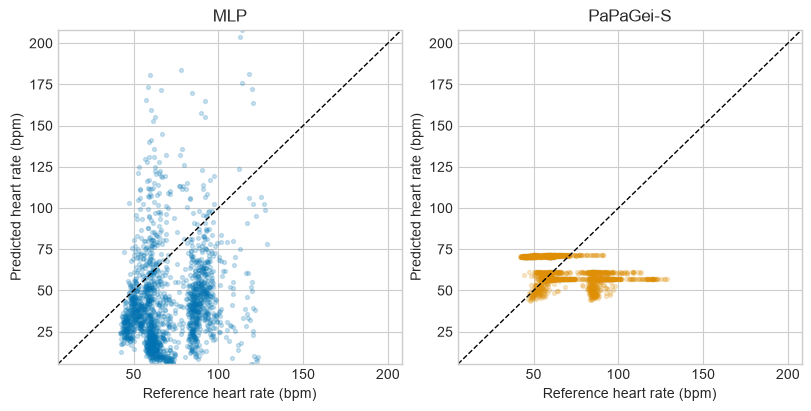

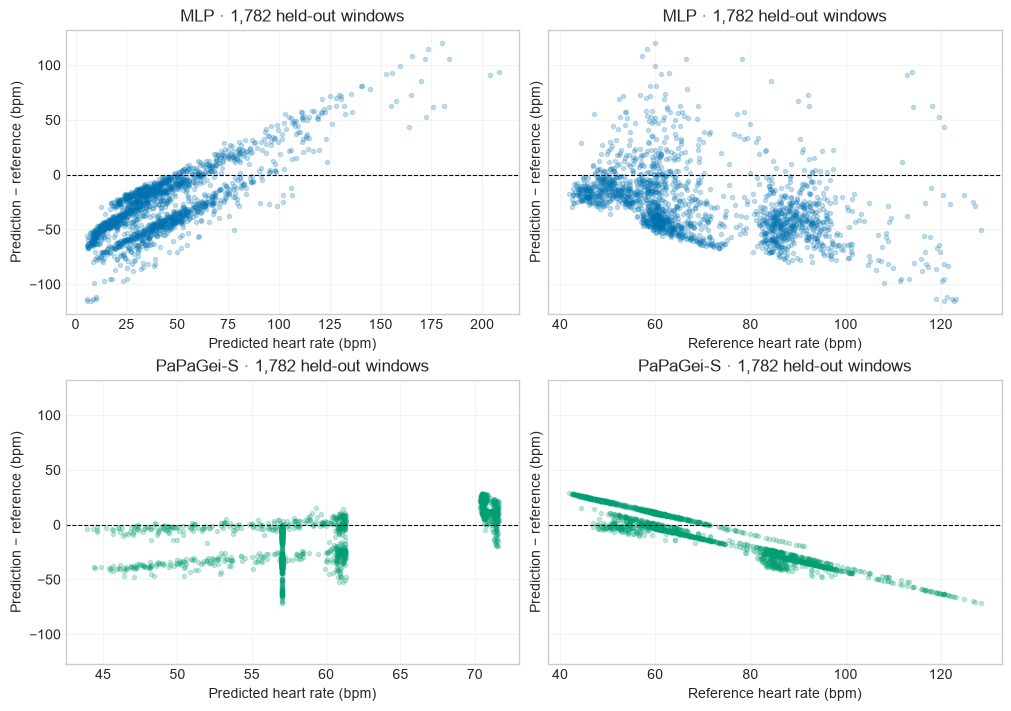

In [13]:
fig = plots.plot_agreement(predictions)
plots.save_figure(fig, FIGURES, '05_prediction_agreement')
plt.show()
fig = plots.plot_error_relationships(predictions, colors=settings['plot_colors'])
plots.save_figure(fig, FIGURES, '06_error_vs_prediction_and_reference')
plt.show()

## 10. Violin plots and subject-level comparison

The first violin plot compares window-level error distributions. The second separates subjects, exposing poor generalization that a pooled score can hide. Window counts and overlapping windows mean the points are not independent replicates. We therefore also report each subject's MAE and RMSE, without presenting window-level uncertainty as subject-level evidence.

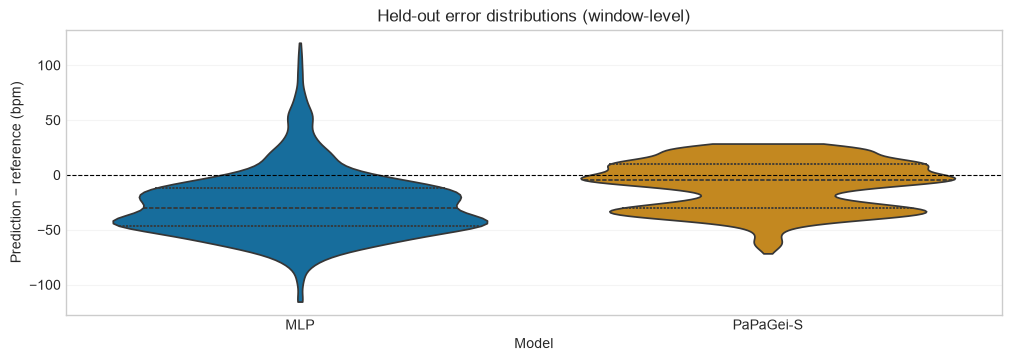

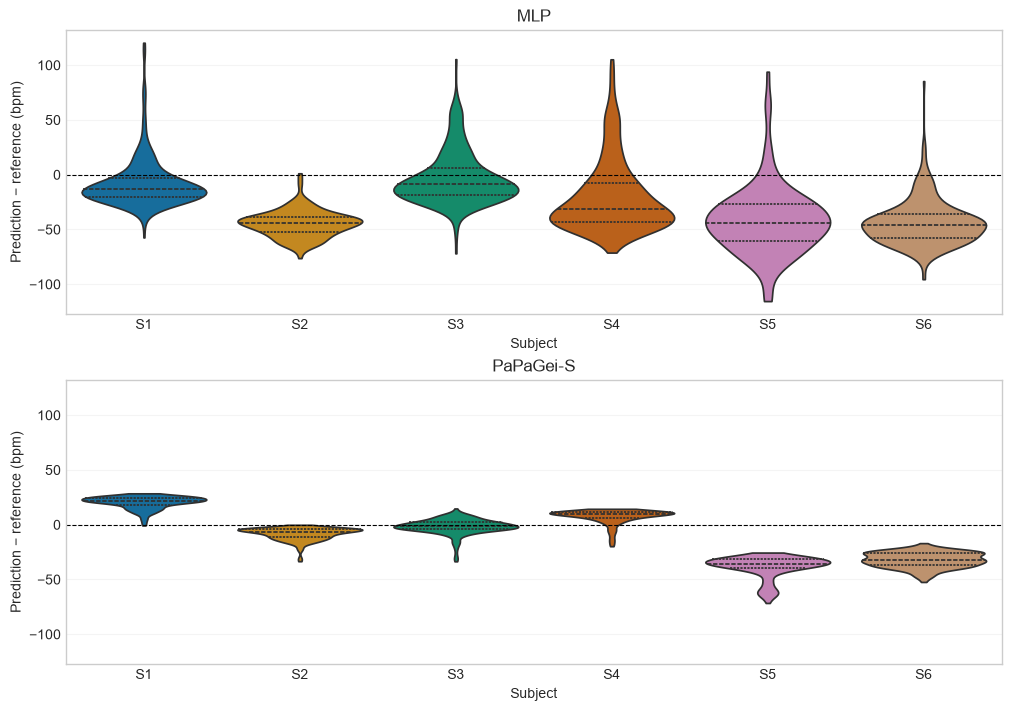

In [14]:
fig = plots.plot_error_violins(predictions)
plots.save_figure(fig, FIGURES, '07_error_violins')
plt.show()
fig = plots.plot_error_violins(predictions, by_subject=True)
plots.save_figure(fig, FIGURES, '08_subject_error_violins')
plt.show()

,model,subject,n,MAE,RMSE,R2,Pearson_r,bias
0,MLP,S3,297,18.810648,23.970331,-8.468153,0.313144,-3.205699
1,MLP,S6,297,45.103199,48.358089,-60.995159,0.229035,-43.777760
2,MLP,S2,297,44.585258,46.201927,-65.182922,0.177744,-44.576473
3,MLP,S5,297,46.845459,52.352901,-24.713495,0.141111,-41.608780
4,MLP,S1,297,18.226160,23.755093,-15.579012,0.602759,-7.669829
5,MLP,S4,297,33.748238,38.114357,-29.274334,0.260730,-19.513615
6,PaPaGei-S,S3,297,4.914523,7.167789,0.153382,0.481465,-1.537386
7,PaPaGei-S,S6,297,32.054253,32.796928,-27.515820,0.288781,-32.054253
8,PaPaGei-S,S2,297,8.405189,10.143399,-2.190016,0.138734,-8.405189
9,PaPaGei-S,S5,297,38.610577,39.967026,-13.985916,0.025277,-38.610577


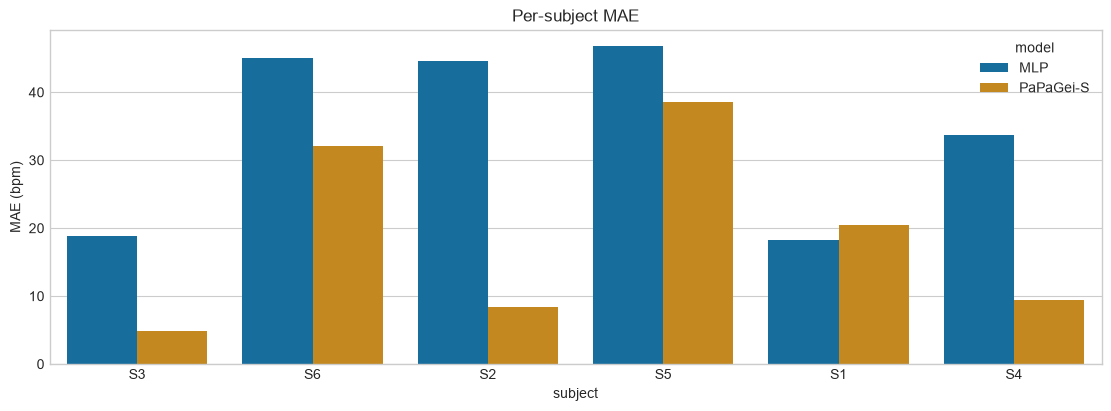

Macro-average over subjects (each subject receives equal weight):


,MAE,RMSE,bias
model,,,
MLP,34.553162,38.792118,-26.725359
PaPaGei-S,18.978268,20.223635,-8.782919


In [15]:
subject_metrics = pipeline.regression_metrics(predictions, by=('model', 'subject'))
display(subject_metrics)
fig = plots.plot_subject_metrics(subject_metrics)
plots.save_figure(fig, FIGURES, '09_subject_MAE')
plt.show()
print('Macro-average over subjects (each subject receives equal weight):')
display(subject_metrics.groupby('model')[['MAE', 'RMSE', 'bias']].mean())

## 11. Error against first and second signal derivatives

A prediction is per window, whereas a derivative is per time point. We summarize each window by its **mean absolute first derivative** and **mean absolute second derivative**, calculated from the same unnormalized processed BVP for every model.

We join these features using the original HDF5 sample index, never row order. Both signed and absolute error are shown. These numerical derivatives are computed with `numpy.gradient` and time spacing 1/fs; no smoothing is applied. Changes in resampling/filtering/amplitude scale can change the feature values.

,model,fold,sample_index,subject,truth,prediction,error,absolute_error,mean_abs_first_derivative,mean_abs_second_derivative,signal_std
0,MLP,0,594,S3,52.904907,36.725071,-16.179836,16.179836,190.934471,2948.317387,31.385813
1,MLP,0,595,S3,52.483284,37.896896,-14.586388,14.586388,200.740773,3010.310029,33.162072
2,MLP,0,596,S3,53.599041,37.674477,-15.924564,15.924564,209.642323,2997.003868,35.519013
3,MLP,0,597,S3,54.576389,42.543964,-12.032425,12.032425,221.877935,3163.386520,37.106957
4,MLP,0,598,S3,55.996521,71.231743,15.235222,15.235222,274.542683,3922.656200,46.155796


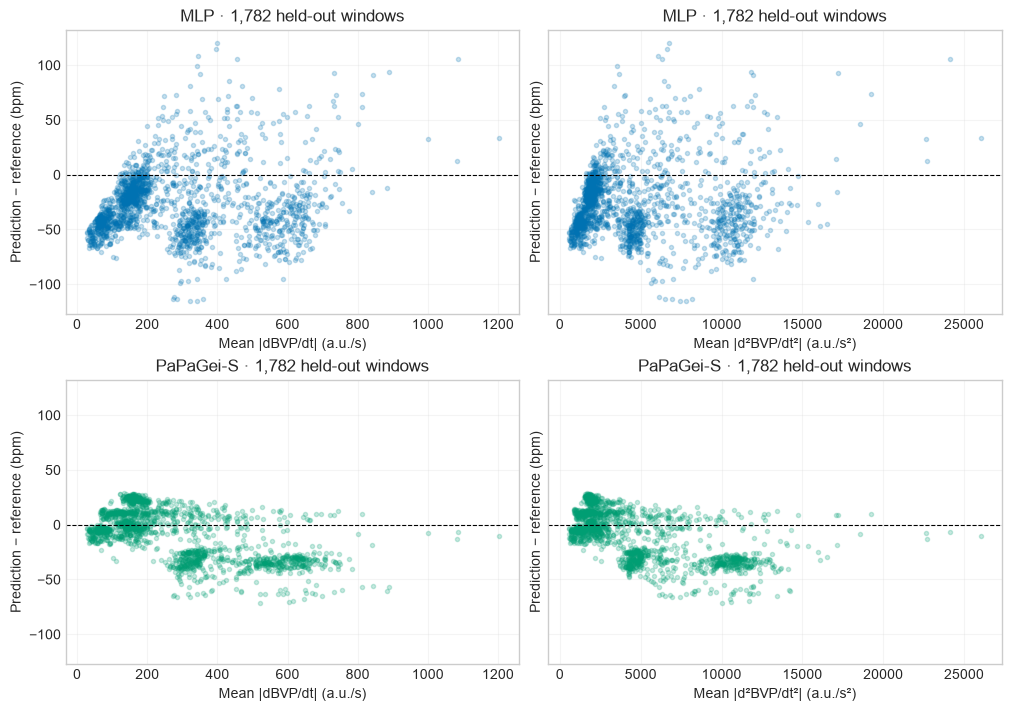

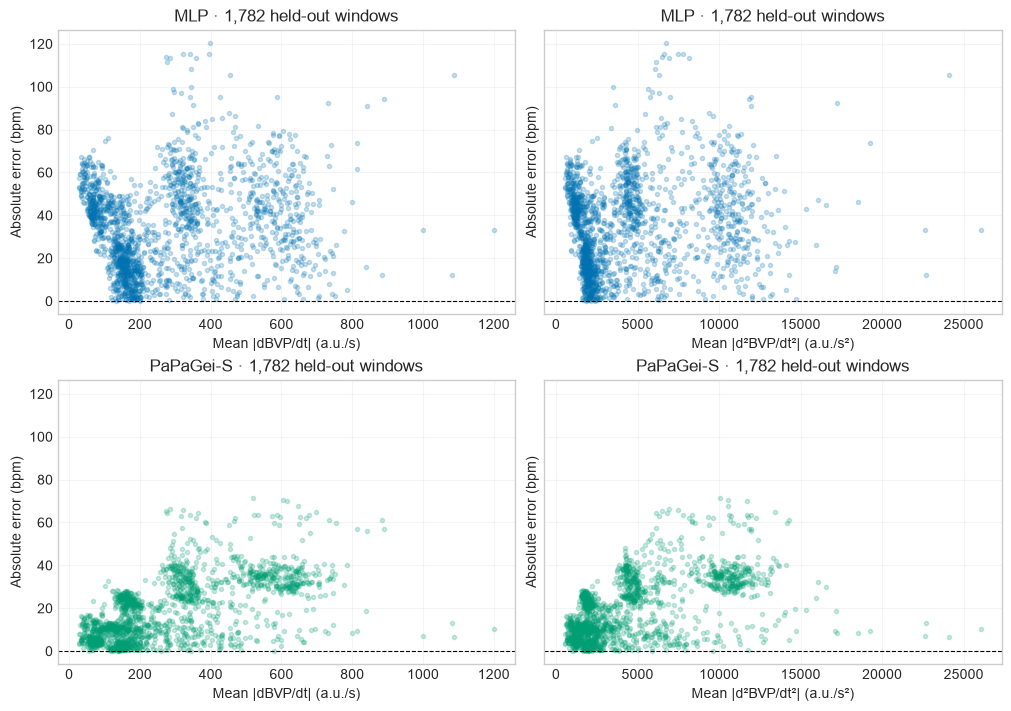

In [16]:
features = pipeline.signal_features(dataset, sample_rate=settings['sample_rate'])
diagnostics = pipeline.join_signal_features(predictions, features)
display(diagnostics.head())
derivative_columns = ('mean_abs_first_derivative', 'mean_abs_second_derivative')
derivative_labels = ('Mean |dBVP/dt| (a.u./s)', 'Mean |d²BVP/dt²| (a.u./s²)')
fig = plots.plot_error_relationships(diagnostics, x_columns=derivative_columns,
                    x_labels=derivative_labels, colors=settings['plot_colors'])
plots.save_figure(fig, FIGURES, '10_signed_error_vs_derivatives')
plt.show()
fig = plots.plot_error_relationships(diagnostics, x_columns=derivative_columns,
                    x_labels=derivative_labels, absolute=True, colors=settings['plot_colors'])
plots.save_figure(fig, FIGURES, '11_absolute_error_vs_derivatives')
plt.show()

## 12. Participant task: change one model choice

**Task:** copy the MLP configuration, change dropout from 0.2 to 0.4, train with the same windows, split artifacts, seed, learning rate and epoch budget, then compare results.

Before running, write a hypothesis: will stronger dropout reduce overfitting, or limit fitting in this small example? Use validation results for tuning. The test plots below are a teaching comparison, not a license to repeatedly optimize against the test subjects.

The following cell is a runnable reference solution. In a live workshop, ask participants to make the edit themselves before revealing it. Suggested further exercises: change hidden size instead; swap the MSE criterion for L1 while holding the rest fixed; run a longer training budget. Change one factor at a time.

In [17]:
exercise_config = deepcopy(mlp_config)
exercise_config['backbone']['params']['dropout_prob'] = 0.4
exercise_config['model_name'] = 'mlp_dropout_exercise'
if RUN_EXERCISE:
    exercise_run = pipeline.run_task(dataset=dataset, base_config=exercise_config,
                    experiment_config=experiment_config, split_path=split_path, transform_path=transform_path,
                    output_dir='results/exercise_dropout', seed=SEED)
    exercise_predictions = pipeline.prediction_table(exercise_run, model_name='MLP exercise')
    comparison = pd.concat([predictions, exercise_predictions], ignore_index=True)
else:
    comparison = predictions.copy()
display(pipeline.regression_metrics(comparison))

2026-10-08 13:29:31,323 - StaticExperimentOrchestrator - INFO - Pre-embedding disabled (backend=torch, frozen=False).


2026-10-08 13:29:31,323 - TorchTrainingBackend - INFO - Resolved training device=cpu, cuda_available=False.


2026-10-08 13:29:31,324 - StaticExperimentOrchestrator - INFO - Reloading original experiment-ready arrays for split 0.


2026-10-08 13:29:31,333 - StaticExperimentOrchestrator - INFO - Applying split-specific transforms for split 0 in RAM (batch_size=64).


Split 0 transform x_0:   0%|          | 0/28 [00:00<?, ?it/s]

...

2026-10-08 13:29:32,701 - TorchTrainingBackend - INFO - Epoch 7/12: train=971.939471 val=1346.971160


2026-10-08 13:29:32,701 - TorchTrainingBackend - INFO - Config 1/1 done: best_val_loss=1322.578130


2026-10-08 13:29:32,893 - StaticExperimentOrchestrator - INFO - Moved fitted split model to CPU after prediction.


Completed static PulsePPG orchestrator run with 3 split payload entries.
Run directory: .\results\exercise_dropout\run_3
Final results CSV: .\results\exercise_dropout\run_3\final_results_exercise_dropout.csv


,model,n,MAE,RMSE,R2,Pearson_r,bias
0,MLP,1782,34.553158,40.425930,-4.146001,0.187606,-26.725357
1,PaPaGei-S,1782,18.978268,23.730955,-0.773292,-0.422765,-8.782920
2,MLP exercise,1782,34.649250,40.292934,-4.112198,0.195365,-27.722998


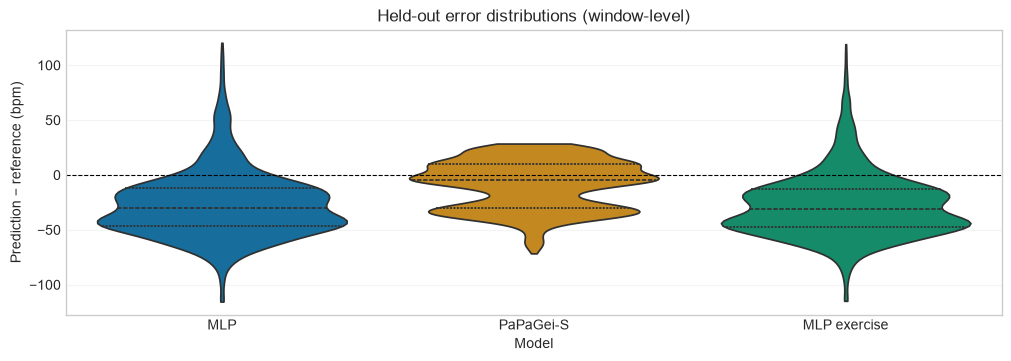

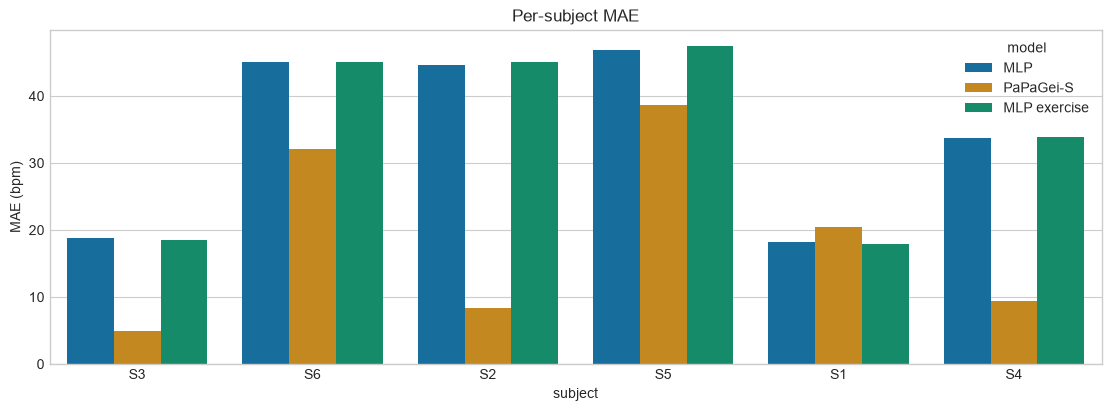

In [18]:
fig = plots.plot_error_violins(comparison)
plots.save_figure(fig, WORKSPACE / 'tasks/exercise/figures', 'exercise_error_violins')
plt.show()
exercise_subject_metrics = pipeline.regression_metrics(comparison, by=('model', 'subject'))
fig = plots.plot_subject_metrics(exercise_subject_metrics)
plots.save_figure(fig, WORKSPACE / 'tasks/exercise/figures', 'exercise_subject_MAE')
plt.show()

## 13. Follow a prediction back to its input

Find a high-error window and inspect its morphology. Ask whether the input seems noisy and whether this pattern occurs for both models. This is descriptive error analysis, not a causal explanation or a saliency method.

,subject,sample_index,truth,prediction,error
2679,S5,1194,128.482880,57.045311,-71.437569
2680,S5,1195,127.304184,57.053925,-70.250259
2678,S5,1193,126.847710,57.048355,-69.799355


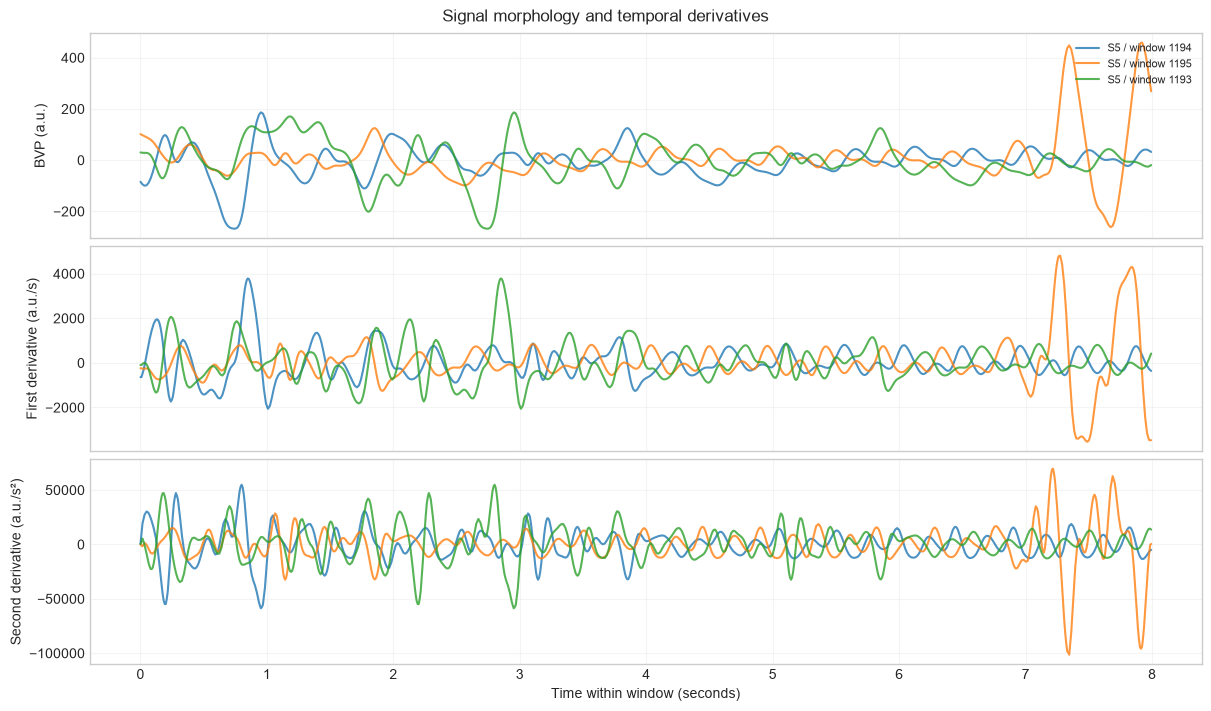

In [19]:
worst = diagnostics.loc[diagnostics.model.eq('PaPaGei-S')].nlargest(3, 'absolute_error')
display(worst[['subject', 'sample_index', 'truth', 'prediction', 'error']])
fig = plots.plot_waveforms(dataset, indices=worst.sample_index.tolist(), sample_rate=settings['sample_rate'])
plots.save_figure(fig, FIGURES, '12_high_error_waveforms')
plt.show()

## 14. Reproducible exports

The runner already saves each run's configurations, predictions and split metadata. We additionally export a tidy comparison table, diagnostic features, pooled metrics, per-subject metrics and software versions. PDF plots remain usable in slides; PNG versions are convenient previews.

In [20]:
OUTPUT = WORKSPACE / 'results/workshop_summary'
OUTPUT.mkdir(parents=True, exist_ok=True)
comparison.to_csv(OUTPUT / 'held_out_predictions.csv', index=False)
pipeline.join_signal_features(comparison, features).to_csv(OUTPUT / 'predictions_with_derivatives.csv', index=False)
pipeline.regression_metrics(comparison).to_csv(OUTPUT / 'pooled_metrics.csv', index=False)
exercise_subject_metrics.to_csv(OUTPUT / 'subject_metrics.csv', index=False)
split_table.to_csv(OUTPUT / 'subject_splits.csv', index=False)
pipeline.save_run_manifest(OUTPUT / 'manifest.json', {
    **settings, 'mode': MODE, 'device': DEVICE, 'exercise_config': exercise_config,
    'mlp_config': mlp_config, 'papagei_config': papagei_config, 'head_config': head_config,
    'experiment_config': experiment_config,
})
print('Tables:', OUTPUT)
print('Figures:', FIGURES)
print('All required comparisons completed.')

Tables: .\results\workshop_summary
Figures: .\figures
All required comparisons completed.


## 15. Discussion and next experiments

- Do pooled scores and equal-subject averages tell the same story?
- Which subject has the largest errors, and does that hold across models?
- Does high absolute derivative magnitude coincide with high error? Could subject identity or heart-rate range explain the pattern?
- How would a longer training budget change the conclusions?
- Why must overlapping windows stay together by subject?
- What would you change to evaluate a different dataset or torch model?

**Extension ideas:** use the full profile, compare MLP head sizes on frozen PaPaGei, try an explicit band-pass preprocessing task, or add a new torch architecture. Regenerate splits and normalization when the dataset changes; update model input dimensions when window duration or sampling rate changes. Keep final test evaluation separate from iterative model selection.

**Scope:** this covers the active torch workflow. The advanced sections below cover the remaining reusable data APIs and Integrated Gradients. Legacy/non-torch backend skeletons and dataset-specific adapters other than DaLiA are not claimed as working examples. The workshop does not reproduce a published PaPaGei benchmark.

**Attribution:** PPG-DaLiA: Reiss, Indlekofer & Schmidt (2019), UCI, DOI 10.24432/C53890 (CC BY 4.0). PaPaGei: Pillai et al., *Open Foundation Models for Optical Physiological Signals*, ICLR 2025; weights DOI 10.5281/zenodo.13983110. See the upstream sources for their notices.

## 16. Streaming HDF5 and framework torch loaders
The processor writes a record-oriented HDF5 before exporting flat model arrays. Disk-backed reading is useful when records do not fit in RAM. We inspect one batch in each mode and then ask the framework to construct a torch DataLoader. These are raw, unnormalized diagnostic batches; the training runner applies the saved split normalization separately.

In [21]:
from ppg_experiment_framework.data_io.h5_loader.loader import H5Loader
from ppg_experiment_framework.data_io.experiment_ready.torch_adapters import make_experiment_ready_dataloader

with pipeline.make_processor(FORMATTED, PROCESSED / 'io_tour', artifact_name='io_tour') as io_processor:
    record_hdf5 = io_processor.load(overwrite_h5=True)
for in_memory in (False, True):
    with H5Loader(record_hdf5, in_memory=in_memory, batch_size=2, labels=['BVP', 'heart_rate']) as loader:
        batch = next(loader.iter_read_batches(batch_size=2))
        print('RAM mode:', in_memory, '| batch records:', len(batch.records), '| labels:', loader.get_labels())
        display(pd.Series(batch.records[0].attributes))
torch_loader = make_experiment_ready_dataloader(dataset, batch_size=16, shuffle=False, in_memory=False)
batch_x, batch_y = next(iter(torch_loader))
print('Torch batch:', batch_x.shape, batch_y.shape)
assert torch.isfinite(batch_x).all() and torch.isfinite(batch_y).all()

2026-10-08 13:29:34,956 - DataProcessor - INFO - Auto-discovered and appended required time label: time_BVP


2026-10-08 13:29:34,957 - DataProcessor - INFO - Auto-discovered and appended required time label: time_heart_rate


2026-10-08 13:29:34,957 - DataProcessor - INFO - Converting .\data\datasets\ppg+dalia\formatted\dalia_quick_125hz_8s to HDF5.


2026-10-08 13:29:34,969 - DataProcessor - INFO - HDF5 conversion complete.


Flushing in-memory dataset to disk:   0%|          | 0/6 [00:00<?, ?rec/s]

...

RAM mode: False | batch records: 2 | labels: ['BVP', 'heart_rate', 'time_BVP', 'time_heart_rate']


recording_id     0
subject_id      S1
task_id         S1
dtype: str

RAM mode: True | batch records: 2 | labels: ['BVP', 'heart_rate', 'time_BVP', 'time_heart_rate']


recording_id     0
subject_id      S1
task_id         S1
dtype: str

Torch batch: torch.Size([16, 1000, 1]) torch.Size([16, 1])


## 17. Filters, custom transforms and fit/apply normalization
We make a separate processing artifact to compare raw, smoothed and normalized signals. `GainTransform` is a small example of how a participant extends the framework: the framework still handles reading, batching and writing.

For this API demonstration, fit normalization on record 0 only and apply it to all records. This is **not** a predictive comparison: the trained models above use their own subject-specific split artifacts. No full-dataset normalization is fed into the benchmark.

2026-10-08 13:29:35,072 - DataProcessor - INFO - Auto-discovered and appended required time label: time_BVP


2026-10-08 13:29:35,072 - DataProcessor - INFO - Auto-discovered and appended required time label: time_heart_rate


2026-10-08 13:29:35,072 - DataProcessor - INFO - Converting .\data\datasets\ppg+dalia\formatted\dalia_quick_125hz_8s to HDF5.


2026-10-08 13:29:35,093 - DataProcessor - INFO - HDF5 conversion complete.


2026-10-08 13:29:35,113 - DataProcessor - INFO - Starting Gain example with processor_backend=sequential.


...

2026-10-08 13:29:35,120 - DataProcessor - INFO - Finished Normalize (z-score): {'batches': 2, 'input_records': 6, 'output_records': 6}.


2026-10-08 13:29:35,120 - DataProcessor - INFO - Starting Impute (mean_flat) with processor_backend=sequential.


2026-10-08 13:29:35,123 - DataProcessor - INFO - Finished Impute (mean_flat): {'batches': 2, 'input_records': 6, 'output_records': 6}.


Flushing in-memory dataset to disk:   0%|          | 0/6 [00:00<?, ?rec/s]

Flushing in-memory dataset to disk: 100%|██████████| 6/6 [00:00<00:00, 1199.92rec/s]

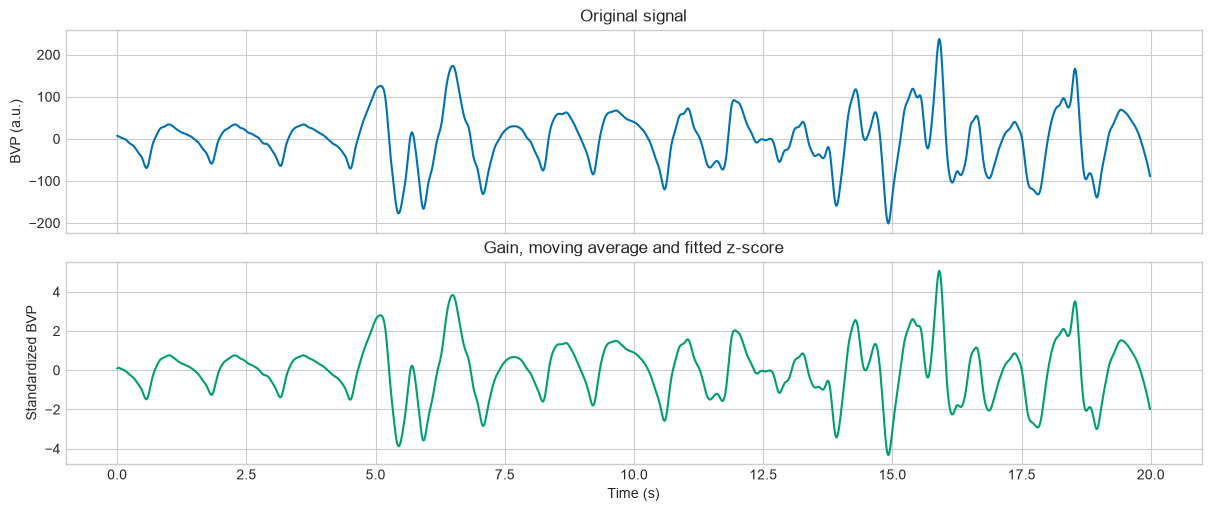

In [22]:
from ppg_experiment_framework.data_processor.transforms import BaseTransform
from ppg_experiment_framework.data_io.h5_loader.backends.backend import H5Record

class GainTransform(BaseTransform):
    """Demonstrate an amplitude transform without changing subject metadata."""
    def __init__(self, labels: list[str], gain: float) -> None:
        self.labels, self.gain = labels, gain

    def __call__(self, record: H5Record) -> list[H5Record]:
        value = dict(record.value)
        for label in self.labels:
            value[label] = np.asarray(value[label], dtype=np.float32) * self.gain
        return [H5Record(index=record.index, value=value, attributes=record.attributes)]

with pipeline.make_processor(FORMATTED, PROCESSED / 'transforms_tour', artifact_name='transforms_tour') as tour:
    tour_hdf5 = tour.load(overwrite_h5=True)
    tour.add_custom_transform(name='Gain example', transform_obj=GainTransform(['BVP'], 0.5), processor_backend='sequential')
    tour.filter(labels=['BVP'], method='moving_average', moving_average_window=5, processor_backend='sequential')
    fitted = tour.fit_normalization(labels=['BVP'], method='z-score', refs=[0])
    tour.apply_normalization(labels=['BVP'], payload=fitted, processor_backend='sequential')
    tour.impute(labels=['BVP'], method='mean_flat', processor_backend='sequential')
with H5Loader(tour_hdf5, in_memory=False, labels=['BVP']) as loader:
    transformed_signal = np.asarray(loader.read(0).value['BVP']).squeeze()
raw_signal = np.asarray(records[0]['value']['BVP']).squeeze()
show_samples = int(20 * metadata['frequency']['BVP'])
time_axis = np.arange(show_samples) / metadata['frequency']['BVP']
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True, constrained_layout=True)
axes[0].plot(time_axis, raw_signal[:show_samples], color='#0072B2')
axes[0].set(ylabel='BVP (a.u.)', title='Original signal')
axes[1].plot(time_axis, transformed_signal[:show_samples], color='#009E73')
axes[1].set(xlabel='Time (s)', ylabel='Standardized BVP', title='Gain, moving average and fitted z-score')
plots.save_figure(fig, FIGURES, '13_transform_comparison')
plt.show()

## 18. Window sequences for temporal models
The framework can group consecutive windows into sequences while retaining recording and subject identity. We create a separate artifact containing four windows per sequence, with a stride of two windows. The simple MLP above expects individual windows; a sequence model needs an appropriate input adapter and architecture. Inspect the new dimensions before selecting that model.

In [23]:
sequence_path = HDF5.parent / f'{ARTIFACT}_sequences.h5'
with pipeline.make_processor(FORMATTED, PROCESSED / 'sequences_tour', artifact_name='sequences_tour') as sequence_processor:
    sequence_processor.load(overwrite_h5=True)
    sequence_processor.resample(labels=['BVP'], target_fs=settings['sample_rate'], processor_backend='sequential')
    sequence_processor.window(biosignal_labels=['BVP'], target_labels=['heart_rate'],
        window_time_seconds=settings['window_seconds'], target_time_label='time_heart_rate',
        signal_time_label='time_BVP', processor_backend='sequential')
    sequence_processor.impute(labels=['heart_rate'], method='complete_case', processor_backend='sequential')
    sequence_processor.window_sequence_prepare(biosignal_labels=['BVP'], target_labels=['heart_rate'],
        sequence_length=4, stride=2, group_by='recording_id', processor_backend='sequential')
    sequence_dataset = sequence_processor.make_experiment_ready(x_train_labels=['BVP'], y_train_labels=['heart_rate'],
        hdf5_path=sequence_path, group_by='subject_id', overwrite=True, verify_integrity=True)
print('Window sequence:', sequence_dataset.is_window_sequence)
print('Input shape:', sequence_dataset.x_arrays[0][:2].shape)
print('Target shape:', sequence_dataset.y_arrays[0][:2].shape)
assert sequence_dataset.is_window_sequence

2026-10-08 13:29:35,913 - DataProcessor - INFO - Auto-discovered and appended required time label: time_BVP


2026-10-08 13:29:35,913 - DataProcessor - INFO - Auto-discovered and appended required time label: time_heart_rate


2026-10-08 13:29:35,914 - DataProcessor - INFO - Converting .\data\datasets\ppg+dalia\formatted\dalia_quick_125hz_8s to HDF5.


2026-10-08 13:29:35,931 - DataProcessor - INFO - HDF5 conversion complete.


2026-10-08 13:29:35,937 - DataProcessor - INFO - Starting Resample (125.0Hz) with processor_backend=sequential.


...

Flushing in-memory dataset to disk: 100%|██████████| 6/6 [00:00<00:00, 676.19rec/s]

Export experiment-ready:   0%|          | 0/6 [00:00<?, ?it/s]

Flushing in-memory dataset to disk:   0%|          | 0/6 [00:00<?, ?rec/s]

Flushing in-memory dataset to disk: 100%|██████████| 6/6 [00:00<00:00, 388.81rec/s]

Window sequence: True
Input shape: (2, 4, 1000, 1)
Target shape: (2, 4, 1)


## 19. Persist sample-wise and batched transformations
Use these APIs for deterministic transforms of exported arrays. The callbacks below only change signal amplitude, so they require no fitted statistics. Any learned transform must instead fit using training subjects and preserve the same split provenance. Each output is a new HDF5; the baseline remains intact.

In [24]:
from ppg_experiment_framework.data_io.experiment_ready.transform import (
    persist_experiment_ready_transformation, persist_experiment_ready_batched_transformation,
)

def scale_sample(x_dict: dict, y_dict: dict, meta: dict) -> tuple[dict, dict]:
    """Scale inputs and retain targets for an illustrative persisted transform."""
    return {key: values * 0.5 for key, values in x_dict.items()}, y_dict

def scale_batch(x_dict: dict, y_dict: dict, meta: dict) -> tuple[dict, dict]:
    """Reuse the same elementwise operation on a batch of windows."""
    return scale_sample(x_dict, y_dict, meta)

sample_scaled = persist_experiment_ready_transformation(source_dataset=dataset,
    output_hdf5_path=HDF5.parent / f'{ARTIFACT}_sample_scaled.h5', transform_fn=scale_sample, overwrite=True)
batch_scaled = persist_experiment_ready_batched_transformation(source_dataset=dataset,
    output_hdf5_path=HDF5.parent / f'{ARTIFACT}_batch_scaled.h5', batch_transform_fn=scale_batch,
    batch_size=128, overwrite=True)
np.testing.assert_allclose(sample_scaled.x_arrays[0][:8], batch_scaled.x_arrays[0][:8])
assert sample_scaled.n_samples == batch_scaled.n_samples == dataset.n_samples
assert sample_scaled.group_keys == dataset.group_keys
print('Sample-wise and batched exports agree; sample identities are preserved.')

Sample-wise and batched exports agree; sample identities are preserved.


## 20. Compare group split strategies
Single holdout, grouped k-fold and leave-one-subject-out answer different evaluation questions. Inspect subject membership before training. We enumerate these alternatives, but do not run another model sweep or select a strategy from test performance.

In [25]:
from ppg_experiment_framework.data_splitters.group_splitters import (
    SingleTrainTestSplitter, KFoldGroupSplitter, LeaveNOutGroupSplitter,
)
strategies = {'Single holdout': SingleTrainTestSplitter(train_fraction=0.67, seed=SEED),
              '3-fold': KFoldGroupSplitter(n_folds=3),
              'Leave one subject out': LeaveNOutGroupSplitter(n_leave_out=1)}
split_rows = []
for name, strategy in strategies.items():
    for fold, (fit_groups, test_groups) in enumerate(strategy.split(dataset)):
        assert set(fit_groups).isdisjoint(test_groups)
        split_rows.append({'strategy': name, 'fold': fold,
                          'fit_subjects': ', '.join(fit_groups), 'test_subjects': ', '.join(test_groups)})
display(pd.DataFrame(split_rows))
print('The runner further separates validation subjects from the fit subjects.')

,strategy,fold,fit_subjects,test_subjects
0,Single holdout,0,"S1, S3, S5, S6","S2, S4"
1,3-fold,0,"S1, S2, S4, S5","S3, S6"
2,3-fold,1,"S1, S3, S4, S6","S2, S5"
3,3-fold,2,"S2, S3, S5, S6","S1, S4"
4,Leave one subject out,0,"S2, S3, S4, S5, S6",S1
5,Leave one subject out,1,"S1, S3, S4, S5, S6",S2
6,Leave one subject out,2,"S1, S2, S4, S5, S6",S3
7,Leave one subject out,3,"S1, S2, S3, S5, S6",S4
8,Leave one subject out,4,"S1, S2, S3, S4, S6",S5
9,Leave one subject out,5,"S1, S2, S3, S4, S5",S6


The runner further separates validation subjects from the fit subjects.


## 21. Integrated Gradients from a saved MLP checkpoint
Attribution asks how a trained model responds to its input relative to a baseline. The framework reconstructs the exact model and split transform, verifies predictions against saved outputs and exports Integrated Gradients with convergence deltas. We explain the MLP here to keep the CPU exercise short.

Take every fourth 8-second window (the source centers are spaced 2 seconds apart) for a non-overlapping inspection subset. The baseline is zero in normalized input space. Inspect convergence diagnostics before interpreting a heatmap; attribution is model sensitivity, not a physiological or causal explanation. Increase integration steps if deltas are large.

IG split_0:   0%|          | 0/10 [00:00<?, ?it/s]

IG split_0:  20%|██        | 2/10 [00:00<00:00, 17.98it/s]

IG split_0:  90%|█████████ | 9/10 [00:00<00:00, 43.28it/s]

IG split_0: 100%|██████████| 10/10 [00:00<00:00, 42.70it/s]

IG split_1:   0%|          | 0/10 [00:00<?, ?it/s]

...

IG split_1: 100%|██████████| 10/10 [00:00<00:00, 59.95it/s]

IG split_2:   0%|          | 0/10 [00:00<?, ?it/s]

IG split_2:  70%|███████   | 7/10 [00:00<00:00, 53.65it/s]

IG split_2: 100%|██████████| 10/10 [00:00<00:00, 59.98it/s]

,label,input_path,n_windows,n_splits,n_steps,source_entry_stride,mae_bpm,median_abs_convergence_delta,p95_abs_convergence_delta,p99_abs_convergence_delta
0,MLP,\ppg-works...,450,3,32,4,34.351864,0.018192,0.071554,0.110961


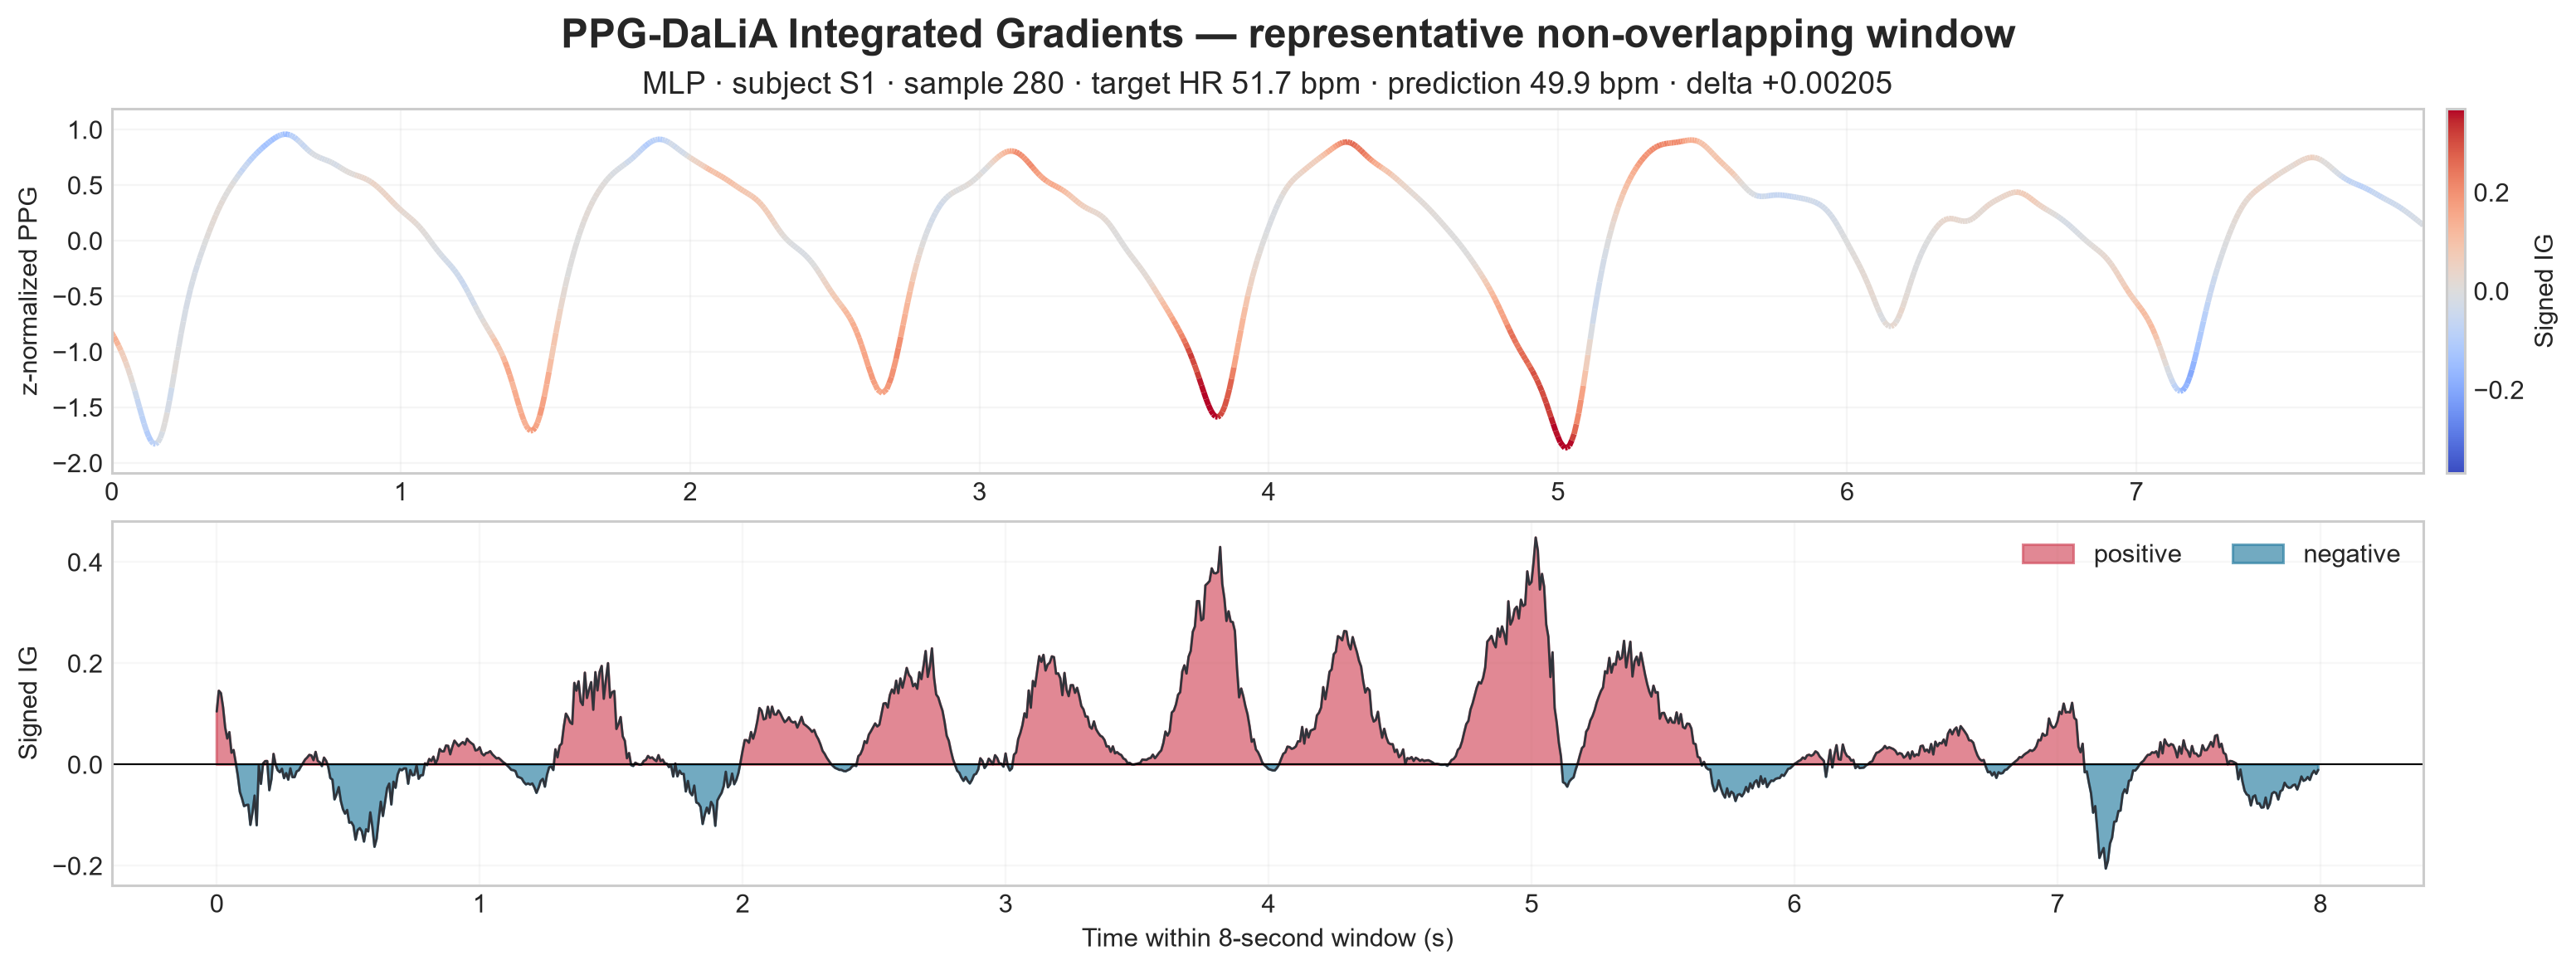

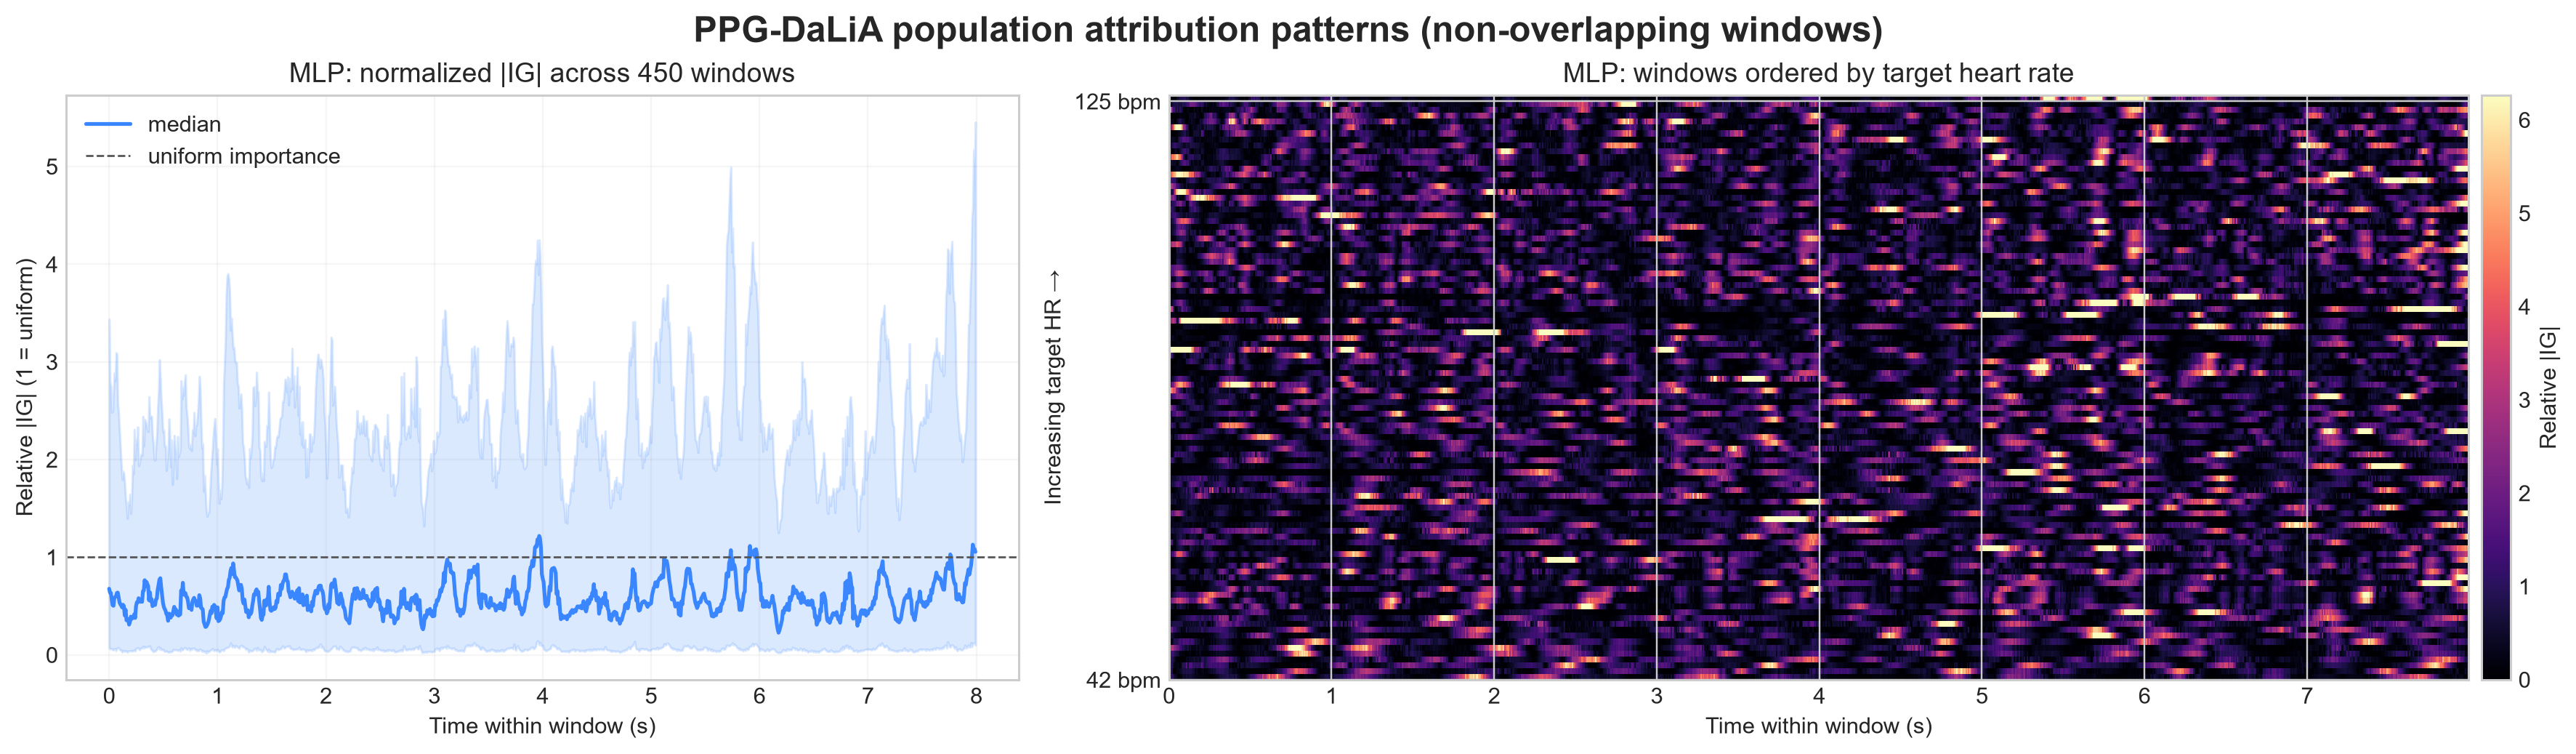

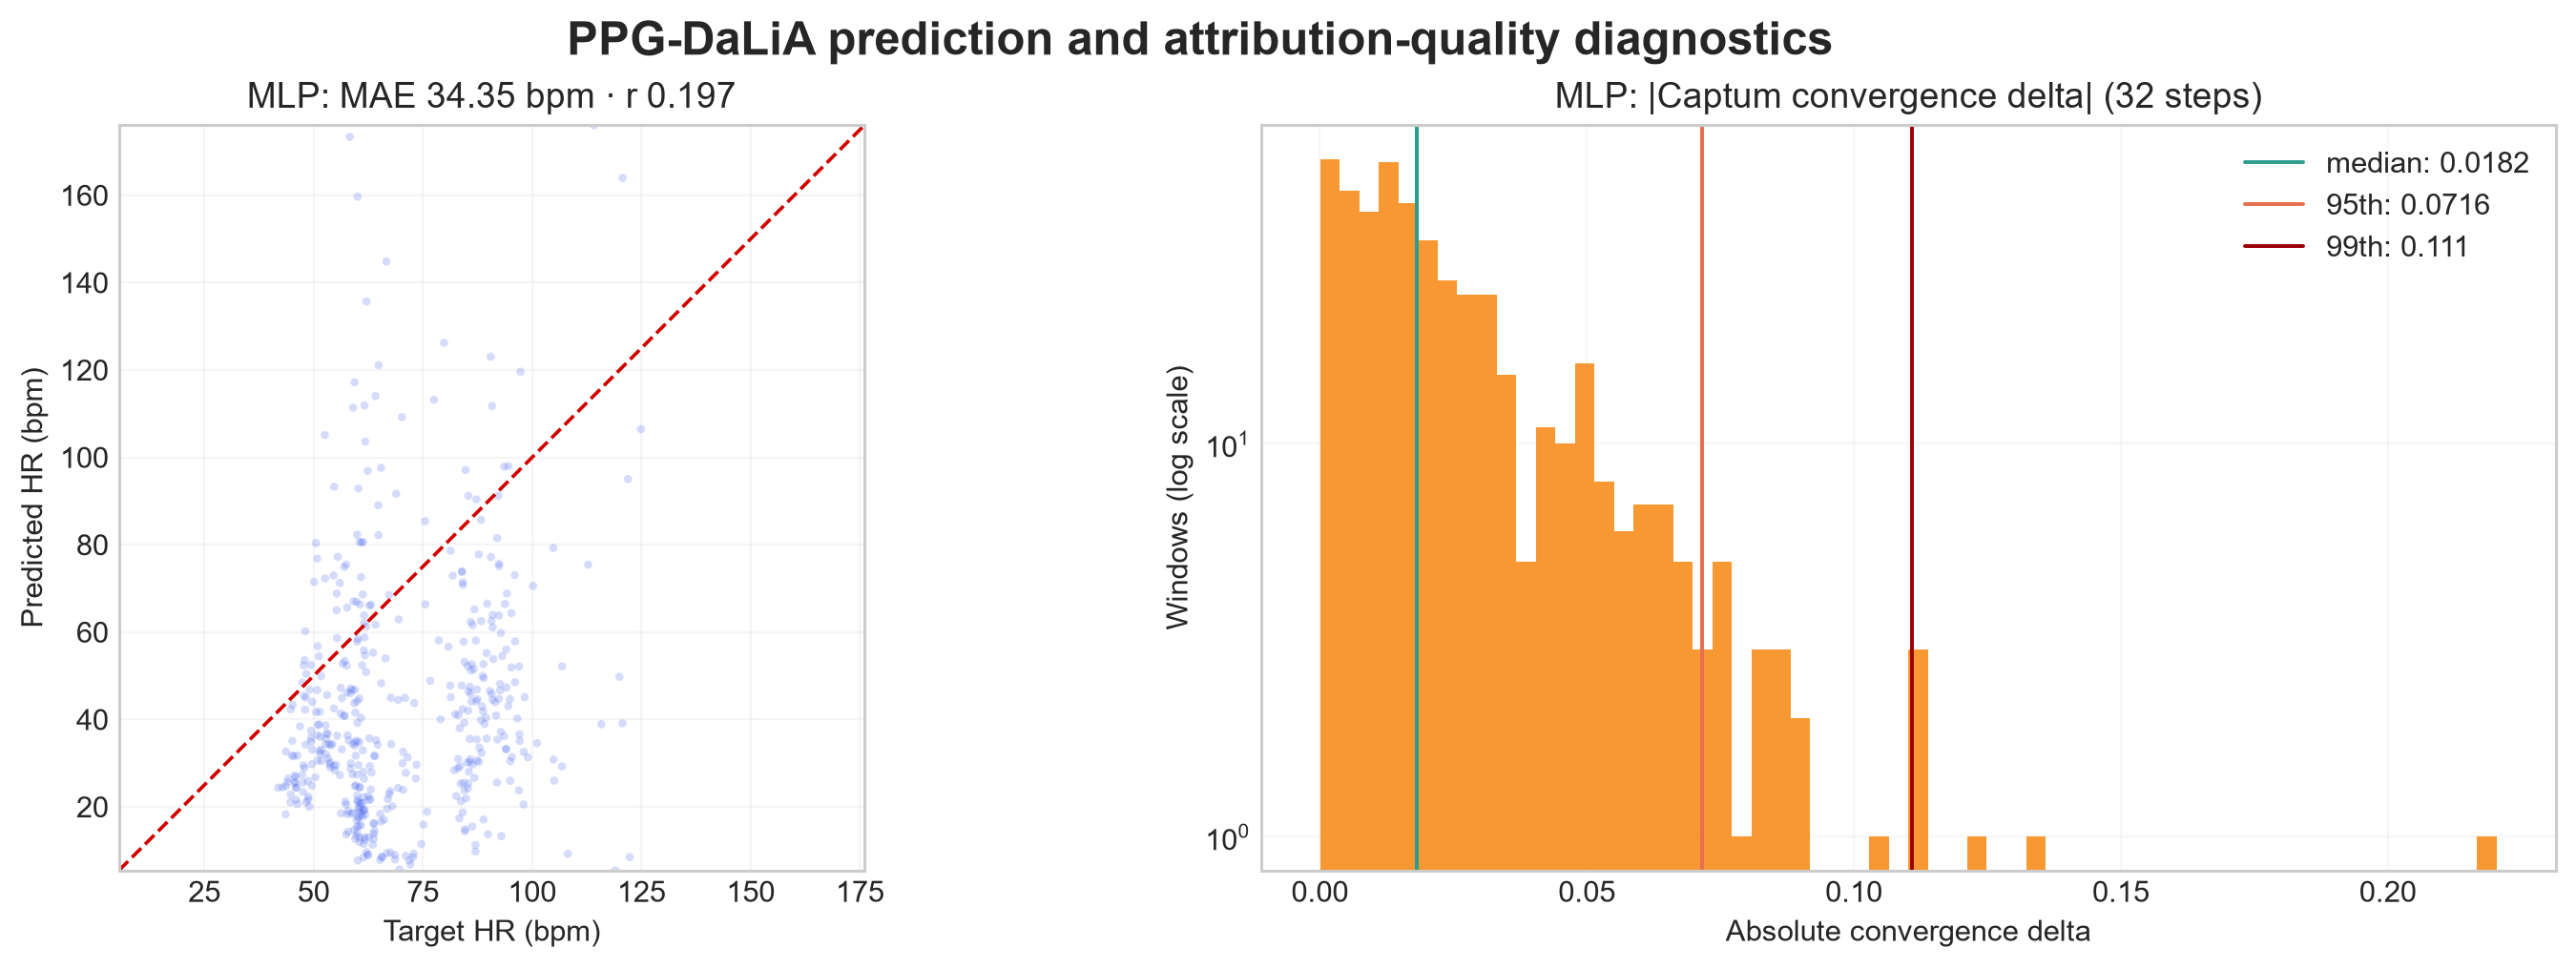

Full data-to-explanation tour complete.


In [26]:
from ppg_experiment_framework.XAI.run_integrated_gradients import export_run_integrated_gradients
from ppg_experiment_framework.XAI.visualize_ppg_dalia_ig import visualize_ppg_dalia_ig
from IPython.display import Image

ig_path = export_run_integrated_gradients(mlp_run['run_dir'], device=DEVICE,
    n_steps=32, batch_size=16, integration_batch_size=8,
    source_entry_stride=4, overwrite=True)
ig_summary = visualize_ppg_dalia_ig([('MLP', ig_path)], output_dir=FIGURES / 'integrated_gradients',
    sampling_rate=settings['sample_rate'], max_heatmap_windows=100)
display(pd.DataFrame(ig_summary['models']))
for figure_path in ig_summary['figures'].values():
    display(Image(filename=str(figure_path)))
print('Full data-to-explanation tour complete.')